# Visualisasi Evaluasi RAG

Notebook ini memvisualisasikan hasil evaluasi retrieval dan generasi untuk 3 metode chunking:
- Element-Based
- MaxMin Semantic
- Recursive

**Scope**: Top-1 hingga Top-20

In [49]:
# Cell 1: Setup dan Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Config
TOPK_MIN = 1
TOPK_MAX = 20
DATA_DIR = Path("../results/final/generation")
FIG_DIR = Path("../results/final/figures20")
GT_DIR = Path("../data/ground_truth")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load data
dfs = []
for k in range(TOPK_MIN, TOPK_MAX + 1):
    pattern = f"eval_*_top{k}.csv"
    files = list(DATA_DIR.glob(pattern))
    if files:
        df = pd.read_csv(files[0])
        df['top_k'] = k
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
qa_gold = pd.read_excel(GT_DIR / "qa_gold_standard_rag_bps_30qa_question_newest.xlsx", sheet_name="qa_gold")
retrieval_labels = pd.read_csv(GT_DIR / "retrieval_labels_final.csv")

# Method name mapping
method_map = {
    'Element-Based': 'Element',
    'MaxMin Semantic': 'MaxMin',
    'Recursive': 'Recursive'
}
data['method_short'] = data['method'].map(method_map)

print(f"Loaded {len(data)} rows (top-{TOPK_MIN} to top-{TOPK_MAX})")
print(f"Methods: {data['method'].unique()}")
print(f"QA gold rows: {len(qa_gold)}")
print(f"Retrieval labels rows: {len(retrieval_labels)}")

Loaded 1800 rows (top-1 to top-20)
Methods: <ArrowStringArray>
['Element-Based', 'MaxMin Semantic', 'Recursive']
Length: 3, dtype: str
QA gold rows: 30
Retrieval labels rows: 416


In [50]:
# Cell 2: Agregasi SEMUA data untuk visualisasi + Definisi fungsi highlight

# 1. Trend Precision, Recall, MRR & F1@k (untuk Chart 1, 2, 3 & 4)
trend = data.groupby(['method_short', 'top_k'])[['precision_at_k', 'recall_at_k', 'mrr', 'f1_at_k']].mean().reset_index()

# 2. Generasi metrik (untuk Chart 5 & 6)
gen_avg = (
    data.groupby(['method_short', 'top_k'])[['bleu', 'rouge_l_recall']]
    .mean()
    .reset_index()
    .rename(columns={'rouge_l_recall': 'rouge_l'})
)

# 3. Hit count (legacy, tidak divisualisasikan dalam urutan chart saat ini)
hit_counts = []
for k in range(TOPK_MIN, TOPK_MAX + 1):
    for method in data['method_short'].unique():
        subset = data[(data['top_k'] == k) & (data['method_short'] == method)]
        n_hit = (subset['mrr'] > 0).sum()
        hit_counts.append({'method': method, 'top_k': k, 'hit_count': n_hit})
hit_df = pd.DataFrame(hit_counts)

# 4. Top-1 data
top5 = data[data['top_k'] == TOPK_MIN].copy()

# 5. Heatmap data (legacy, tidak divisualisasikan dalam urutan chart saat ini)
heatmap_data = top5.pivot_table(
    index='query_id',
    columns='method_short',
    values='mrr',
    aggfunc='mean'
).fillna(0)

# 6. Ground truth summary data (untuk Chart 7 & 8)
qa_evidence_counts = (
    qa_gold['evidence_type']
    .fillna('Unknown')
    .replace('', 'Unknown')
    .value_counts()
    .rename_axis('Evidence Type')
    .reset_index(name='Count')
)

label_counts = (
    retrieval_labels['label']
    .value_counts()
    .sort_index()
    .rename_axis('Label')
    .reset_index(name='Count')
)
label_counts['Label Name'] = label_counts['Label'].map({0: '0 = Tidak Relevan', 1: '1 = Relevan'}).fillna(label_counts['Label'].astype(str))


# Label semua titik Top-k agar setiap nilai Top-1 sampai Top-20 terlihat.
LABEL_TOPK_VALUES = set(range(TOPK_MIN, TOPK_MAX + 1))


def should_label_topk(top_k):
    return int(top_k) in LABEL_TOPK_VALUES



def dense_tail_offset(method, top_k, pattern='balanced'):
    """Offset label untuk Top-11..Top-20 agar tidak menumpuk di area padat."""
    top_k = int(top_k)
    if top_k <= 10:
        return None

    x_shift = -8 if top_k % 2 == 0 else 8
    patterns = {
        'precision': {
            'Element': (x_shift - 4, -16),
            'MaxMin': (x_shift, -24),
            'Recursive': (x_shift + 4, 16),
        },
        'recall': {
            'Element': (x_shift - 4, -16),
            'MaxMin': (x_shift, 16),
            'Recursive': (x_shift + 4, -16),
        },
        'mrr': {
            'Element': (x_shift - 4, -16),
            'MaxMin': (x_shift, -24),
            'Recursive': (x_shift + 4, 16),
        },
        'f1': {
            'Element': (x_shift - 4, -16),
            'MaxMin': (x_shift, -24),
            'Recursive': (x_shift + 4, 16),
        },
        'bleu': {
            'Element': (x_shift - 4, -16),
            'MaxMin': (x_shift, -24),
            'Recursive': (x_shift + 4, 16),
        },
        'rouge': {
            'Element': (x_shift - 4, 16),
            'MaxMin': (x_shift, -18),
            'Recursive': (x_shift + 4, -16),
        },
    }
    return patterns.get(pattern, patterns['precision']).get(method)


def resolve_label_offset(custom_offsets, method, top_k, default_offset, pattern):
    """Prioritaskan offset manual Top-1..10, lalu offset padat Top-11..20."""
    top_k = int(top_k)
    if (method, top_k) in custom_offsets:
        return custom_offsets[(method, top_k)]
    tail_offset = dense_tail_offset(method, top_k, pattern=pattern)
    return tail_offset if tail_offset is not None else default_offset

def highlight_max_only(s):
    """Bold hanya nilai maksimum tanpa memberi background color."""
    is_max = s == s.max()
    return ['font-weight: 700' if v else '' for v in is_max]


def format_metric_table(df, axis=1, fmt='{:.4f}'):
    """Render tabel center-align dan bold-only untuk nilai terbesar."""
    return (
        df.style
        .format(fmt)
        .apply(highlight_max_only, axis=axis)
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'center')]},
        ])
    )


METHOD_LABEL_OFFSETS = {
    'Element': (0, 18),
    'MaxMin': (0, -18),
    'Recursive': (0, 18),
}


def annotate_grouped_line_points(ax, df, x_col, y_col, label_col='method_short', fontsize=9):
    """Tempatkan label menjauh dari garis, terutama saat nilai antar metode berdekatan."""
    close_threshold = 0.018
    close_cluster_offsets = [(0, 18), (0, -18), (0, 30)]
    label_positions = {}

    for _, group in df.groupby(x_col):
        sorted_group = group.sort_values(y_col, ascending=False).reset_index().rename(columns={'index': '_row_id'})
        used = set()
        for idx, row in sorted_group.iterrows():
            if idx in used:
                continue
            cluster = [idx]
            used.add(idx)
            for next_idx in range(idx + 1, len(sorted_group)):
                if abs(row[y_col] - sorted_group.loc[next_idx, y_col]) <= close_threshold:
                    cluster.append(next_idx)
                    used.add(next_idx)

            if len(cluster) == 1:
                cluster_row = sorted_group.loc[cluster[0]]
                label_positions[cluster_row['_row_id'], cluster_row[label_col], cluster_row[x_col]] = METHOD_LABEL_OFFSETS.get(
                    cluster_row[label_col], (0, 14)
                )
            else:
                for offset_idx, cluster_idx in enumerate(cluster):
                    cluster_row = sorted_group.loc[cluster_idx]
                    label_positions[cluster_row['_row_id'], cluster_row[label_col], cluster_row[x_col]] = close_cluster_offsets[
                        min(offset_idx, len(close_cluster_offsets) - 1)
                    ]

    for _, row in df.iterrows():
        if not should_label_topk(row[x_col]):
            continue
        x_offset, y_offset = label_positions.get(
            (row.name, row[label_col], row[x_col]),
            resolve_label_offset({}, row[label_col], row[x_col], METHOD_LABEL_OFFSETS.get(row[label_col], (0, 14)), 'mrr')
        )
        valign = 'bottom' if y_offset >= 0 else 'top'
        ax.annotate(
            f"{row[y_col]:.3f}",
            (row[x_col], row[y_col]),
            textcoords='offset points',
            xytext=(x_offset, y_offset),
            ha='center',
            va=valign,
            fontsize=fontsize,
            color='#374151',
            bbox=dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.78)
        )


def pad_y_axis(ax, values, pad_ratio=0.18):
    """Tambah ruang vertikal agar label tidak kepotong di tepi chart."""
    y_min = float(values.min())
    y_max = float(values.max())
    span = y_max - y_min
    pad = max(span * pad_ratio, 0.015)
    ax.set_ylim(y_min - pad, y_max + pad)

print('Agregasi data selesai:')
print(f"  - trend: {len(trend)} rows")
print(f"  - gen_avg: {len(gen_avg)} rows")
print(f"  - hit_df: {len(hit_df)} rows")
print(f"  - top5: {len(top5)} rows")
print(f"  - heatmap_data: {heatmap_data.shape}")
print(f"  - qa_evidence_counts: {len(qa_evidence_counts)} rows")
print(f"  - label_counts: {len(label_counts)} rows")

Agregasi data selesai:
  - trend: 60 rows
  - gen_avg: 60 rows
  - hit_df: 60 rows
  - top5: 90 rows
  - heatmap_data: (30, 3)
  - qa_evidence_counts: 4 rows
  - label_counts: 2 rows


## Chart 1: Trend Precision@k vs Top-k

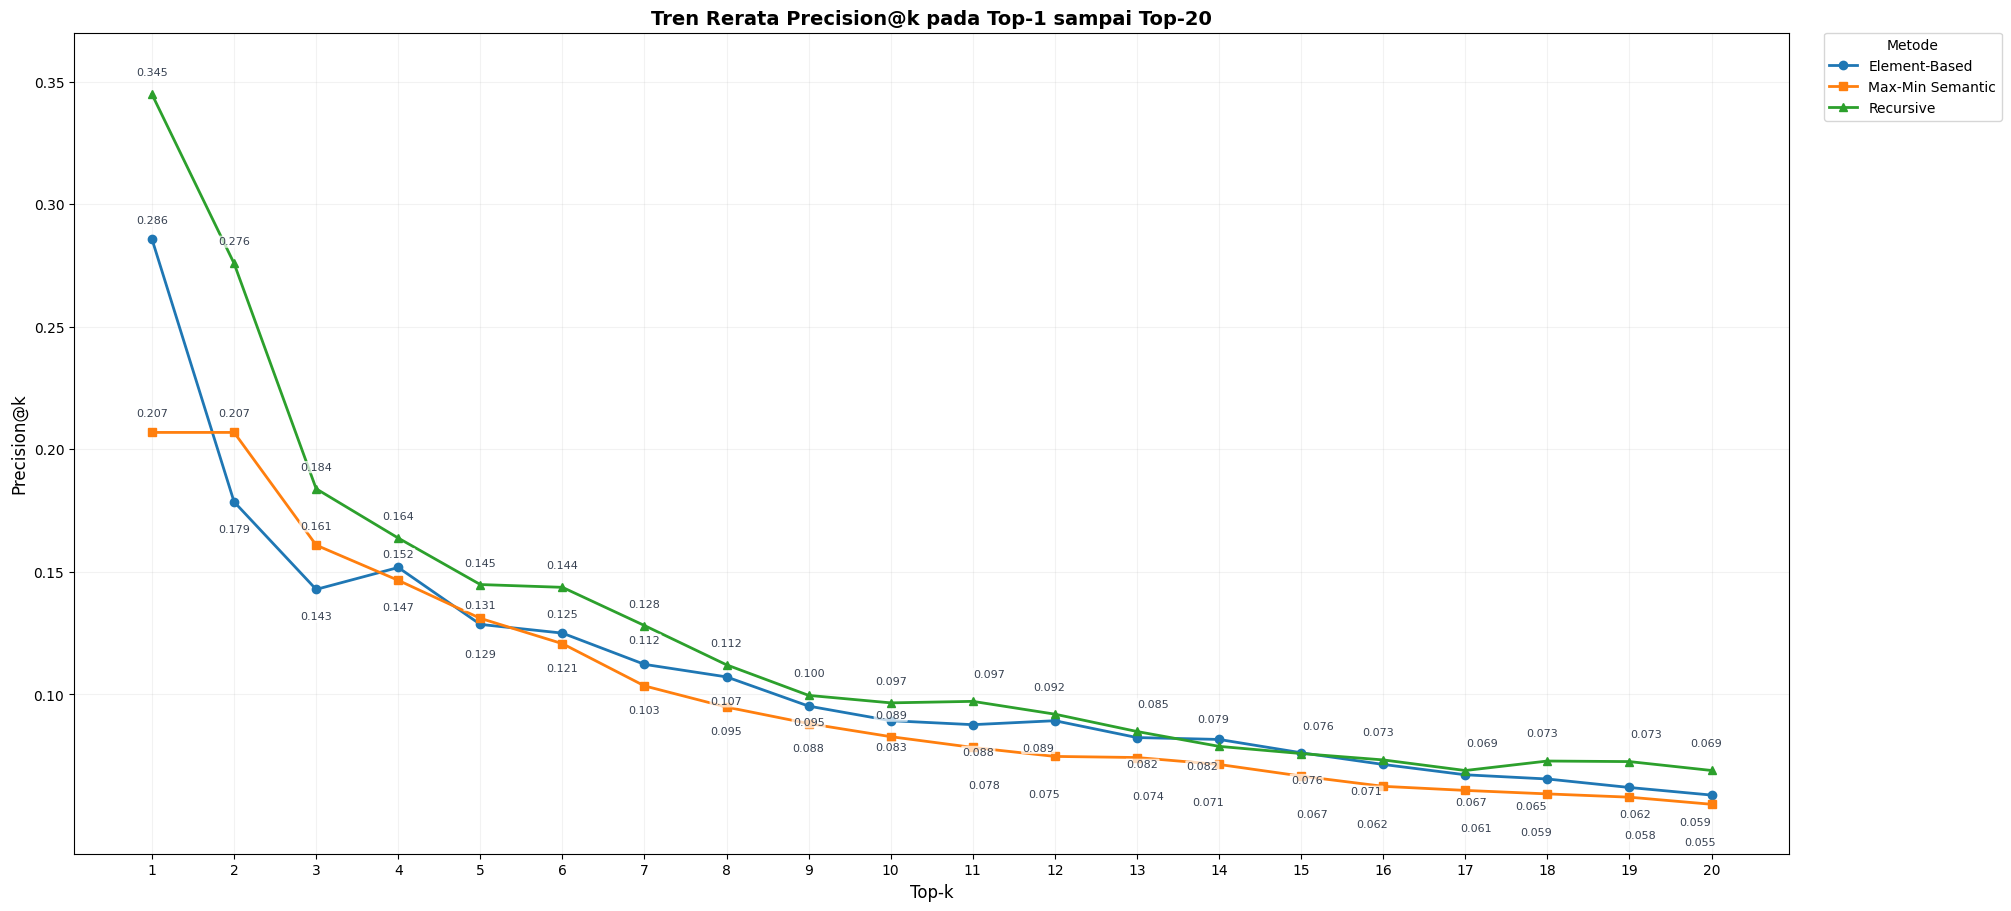

Chart 1 saved

Tabel 1: Precision@k per Metode dan Top-k


Method,Element,MaxMin,Recursive
Top-k,,,
1,0.2857,0.2069,0.3448
2,0.1786,0.2069,0.2759
3,0.1428,0.1609,0.1839
4,0.1518,0.1466,0.1638
5,0.1286,0.1310,0.1448
6,0.1250,0.1207,0.1437
7,0.1123,0.1035,0.1281
8,0.1071,0.0948,0.1121
9,0.0952,0.0881,0.0996


Table 1 exported


In [51]:
# Chart 1 + Tabel 1: Precision trend (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(20, 9), constrained_layout=True)
method_display_labels = {
    'Element': 'Element-Based',
    'MaxMin': 'Max-Min Semantic',
    'Recursive': 'Recursive',
}
method_line_styles = {
    'Element': {'marker': 'o', 'linestyle': '-'},
    'MaxMin': {'marker': 's', 'linestyle': '-'},
    'Recursive': {'marker': '^', 'linestyle': '-'},
}
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    style = method_line_styles[method]
    ax.plot(
        subset['top_k'],
        subset['precision_at_k'],
        marker=style['marker'],
        linestyle=style['linestyle'],
        label=method_display_labels[method],
        linewidth=2,
        markersize=6,
    )

precision_label_offsets = {
    ('Element', 2): (0, -16),
    ('Element', 3): (0, -16),
    ('MaxMin', 4): (0, -16),
    ('Element', 4): (0, 6),
    ('Element', 7): (0, 6),
    ('Element', 8): (0, -6),
    ('Element', 9): (0, -6),
    ('Element', 5): (0, -18),
    ('MaxMin', 5): (0, 6),
    ('MaxMin', 6): (0, -14),
    ('MaxMin', 7): (0, -14),
    ('Element', 7): (0, 14),
    ('Element', 8): (0, -14),
    ('Element', 9): (0, -8),
    ('Element', 10): (0, 0),
    ('MaxMin', 8): (0, -14),
    ('MaxMin', 9): (0, -14),
    ('MaxMin', 10): (0, -4),
}
precision_default_offsets = {
    'Element': (0, 10),
    'MaxMin': (0, 10),
    'Recursive': (0, 12),
}
for _, row in trend.iterrows():
    if not should_label_topk(row['top_k']):
        continue
    x_offset, y_offset = resolve_label_offset(
        precision_label_offsets,
        row['method_short'],
        row['top_k'],
        precision_default_offsets[row['method_short']],
        'precision'
    )
    ax.annotate(
        f"{row['precision_at_k']:.3f}",
        (row['top_k'], row['precision_at_k']),
        textcoords='offset points',
        xytext=(x_offset, y_offset),
        ha='center',
        va='bottom' if y_offset >= 0 else 'top',
        fontsize=8,
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.72)
    )

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('Precision@k', fontsize=12)
ax.set_title('Tren Rerata Precision@k pada Top-1 sampai Top-20', fontsize=14, fontweight='bold')
ax.legend(title='Metode', fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.minorticks_off()
ax.grid(True, which='major', axis='both', alpha=0.16, linewidth=0.8)
ax.set_xticks(range(TOPK_MIN, TOPK_MAX + 1))
ax.set_ylim(0.035, 0.37)
precision_yticks = np.round(np.arange(0.10, 0.371, 0.05), 2)
ax.set_yticks(precision_yticks)
ax.set_yticklabels([f'{tick:.2f}' for tick in precision_yticks])

plt.savefig(FIG_DIR / 'chart1_precision_trend.png', dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()
print('Chart 1 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table1 = (
    trend.pivot(index='top_k', columns='method_short', values='precision_at_k')
    .rename_axis(index='Top-k', columns='Method')
)
print('\nTabel 1: Precision@k per Metode dan Top-k')
styled_table1 = format_metric_table(table1, axis=1)
display(styled_table1)

# Export CSV
table1.to_csv(FIG_DIR / 'table1_precision_trend.csv')
print('Table 1 exported')

## Chart 2: Trend Recall@k vs Top-k

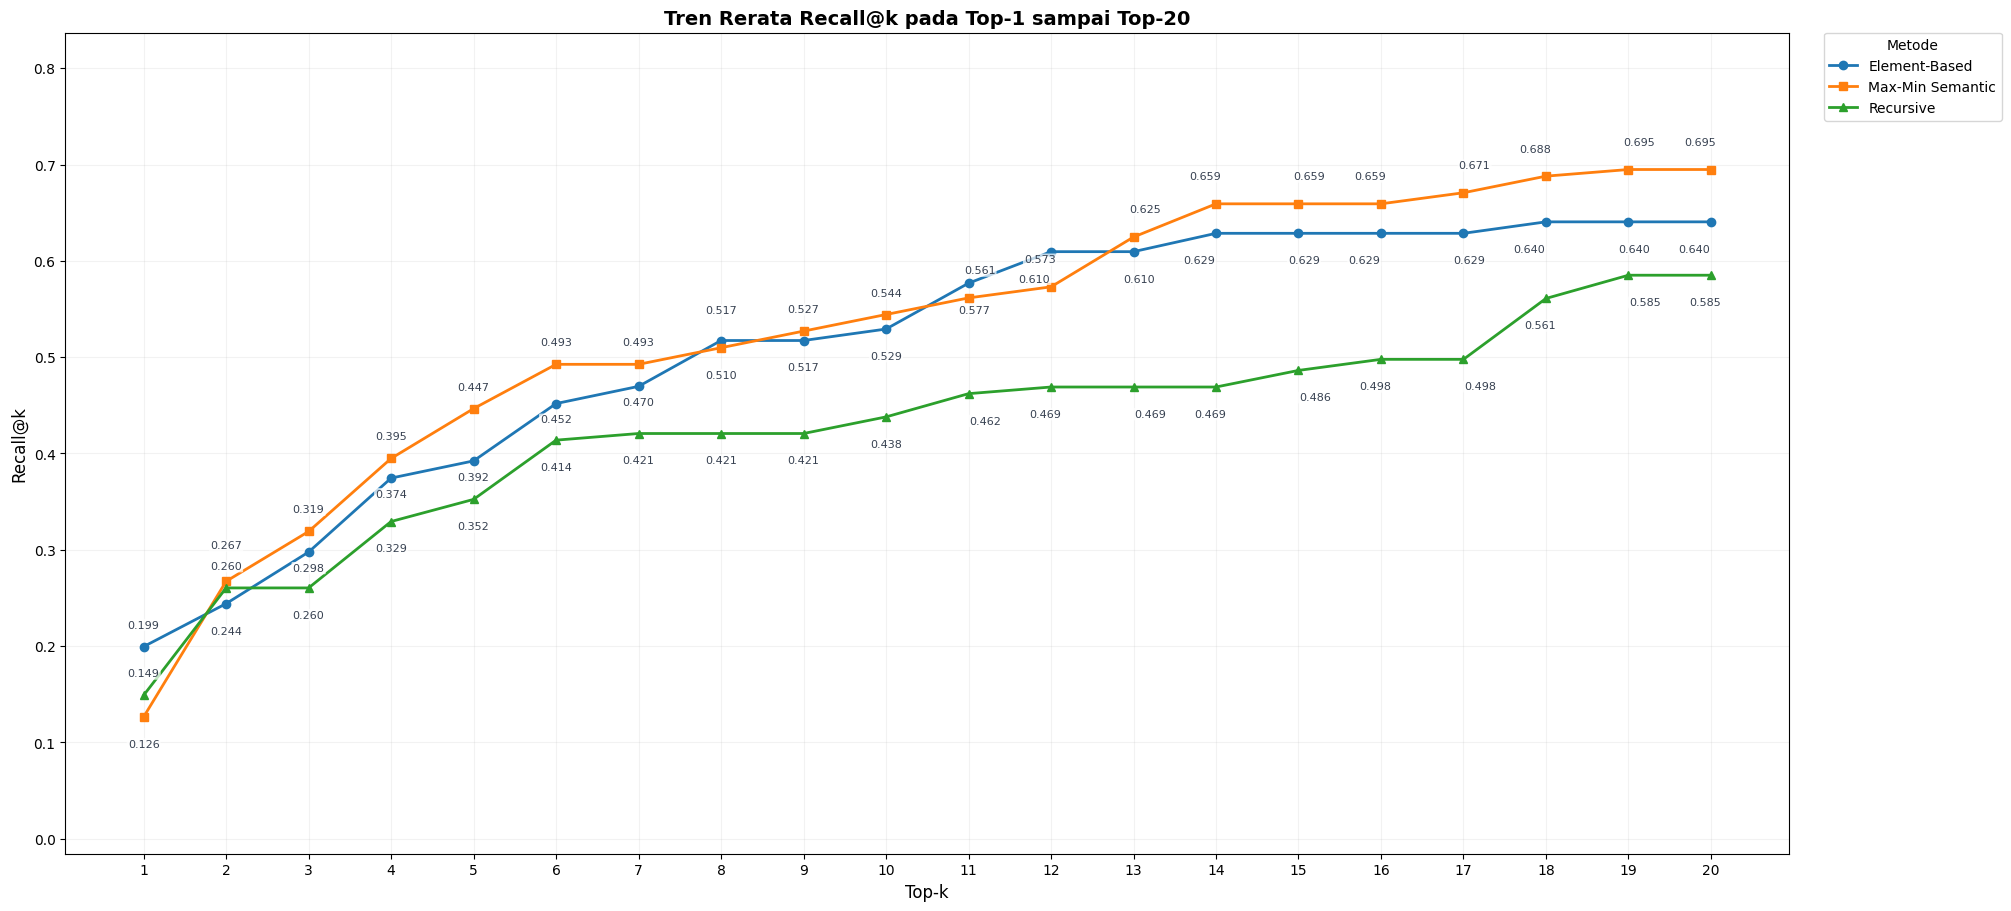

Chart 2 saved

Tabel 2: Recall@k per Metode dan Top-k


Method,Element,MaxMin,Recursive
Top-k,,,
1,0.1994,0.1264,0.1488
2,0.2440,0.2672,0.2603
3,0.2976,0.3190,0.2603
4,0.3744,0.3948,0.3293
5,0.3923,0.4466,0.3523
6,0.4518,0.4925,0.4138
7,0.4696,0.4925,0.4207
8,0.5173,0.5098,0.4207
9,0.5173,0.5270,0.4207


Table 2 exported


In [52]:
# Chart 2 + Tabel 2: Recall trend (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(20, 9), constrained_layout=True)
method_display_labels = {
    'Element': 'Element-Based',
    'MaxMin': 'Max-Min Semantic',
    'Recursive': 'Recursive',
}
method_line_styles = {
    'Element': {'marker': 'o', 'linestyle': '-'},
    'MaxMin': {'marker': 's', 'linestyle': '-'},
    'Recursive': {'marker': '^', 'linestyle': '-'},
}
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    style = method_line_styles[method]
    ax.plot(
        subset['top_k'],
        subset['recall_at_k'],
        marker=style['marker'],
        linestyle=style['linestyle'],
        label=method_display_labels[method],
        linewidth=2,
        markersize=6,
    )

recall_label_offsets = {
    ('MaxMin', 1): (0, -16),
    ('Element', 2): (0, -16),
    ('Element', 3): (0, -8),
    ('Element', 4): (0, -8),
    ('Element', 5): (0, -8),
    ('Element', 6): (0, -8),
    ('Element', 7): (0, -8),
    ('Element', 8): (0, 18),
    ('Recursive', 3): (0, -16),
    ('Recursive', 4): (0, -16),
    ('Recursive', 5): (0, -16),
    ('Recursive', 6): (0, -16),
    ('Recursive', 7): (0, -16),
    ('Recursive', 8): (0, -16),
    ('Recursive', 9): (0, -16),
    ('Recursive', 10): (0, -16),
    ('MaxMin', 2): (0, 22),
    ('MaxMin', 8): (0, -16),
    ('Element', 9): (0, -16),
    ('Element', 10): (0, -16),
}
recall_default_offsets = {
    'Element': (0, 12),
    'MaxMin': (0, 12),
    'Recursive': (0, 12),
}
for _, row in trend.iterrows():
    if not should_label_topk(row['top_k']):
        continue
    x_offset, y_offset = resolve_label_offset(
        recall_label_offsets,
        row['method_short'],
        row['top_k'],
        recall_default_offsets[row['method_short']],
        'recall'
    )
    ax.annotate(
        f"{row['recall_at_k']:.3f}",
        (row['top_k'], row['recall_at_k']),
        textcoords='offset points',
        xytext=(x_offset, y_offset),
        ha='center',
        va='bottom' if y_offset >= 0 else 'top',
        fontsize=8,
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.72)
    )

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('Recall@k', fontsize=12)
ax.set_title('Tren Rerata Recall@k pada Top-1 sampai Top-20', fontsize=14, fontweight='bold')
ax.legend(title='Metode', fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.minorticks_off()
ax.grid(True, which='major', axis='both', alpha=0.16, linewidth=0.8)
ax.set_xticks(range(TOPK_MIN, TOPK_MAX + 1))
pad_y_axis(ax, trend['recall_at_k'], pad_ratio=0.25)

plt.savefig(FIG_DIR / 'chart2_recall_trend.png', dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()
print('Chart 2 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table2 = (
    trend.pivot(index='top_k', columns='method_short', values='recall_at_k')
    .rename_axis(index='Top-k', columns='Method')
)
print('\nTabel 2: Recall@k per Metode dan Top-k')
styled_table2 = format_metric_table(table2, axis=1)
display(styled_table2)

# Export CSV
table2.to_csv(FIG_DIR / 'table2_recall_trend.csv')
print('Table 2 exported')

## Chart 3: Trend MRR vs Top-k

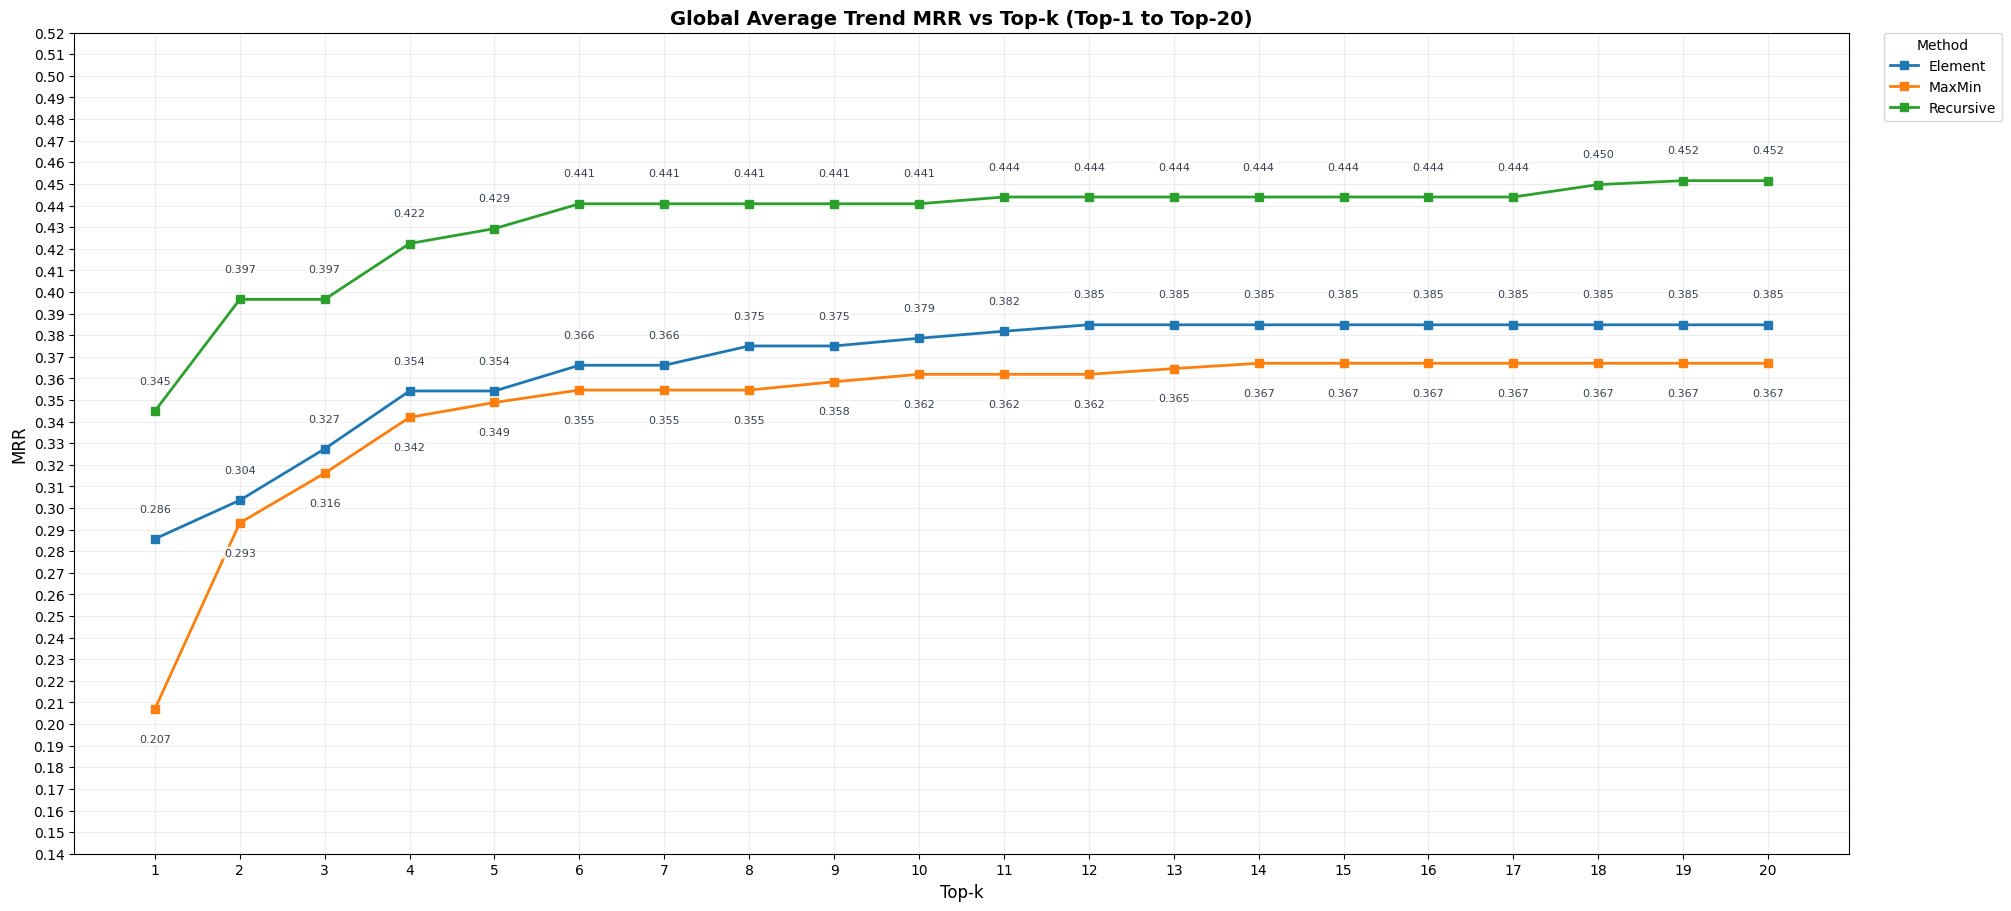

Chart 3 saved

Tabel 3: Global Average MRR per Metode dan Top-k


Method,Element,MaxMin,Recursive
Top-k,,,
1,0.2857,0.2069,0.3448
2,0.3036,0.2931,0.3966
3,0.3274,0.3161,0.3966
4,0.3542,0.3420,0.4224
5,0.3542,0.3488,0.4293
6,0.3661,0.3546,0.4408
7,0.3661,0.3546,0.4408
8,0.3750,0.3546,0.4408
9,0.3750,0.3584,0.4408


Table 3 exported


In [53]:
# Chart 3 + Tabel 3: MRR trend (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(20, 9), constrained_layout=True)
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    ax.plot(subset['top_k'], subset['mrr'], marker='s', label=method, linewidth=2)
annotate_grouped_line_points(ax, trend, 'top_k', 'mrr', fontsize=8)

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('MRR', fontsize=12)
ax.set_title('Global Average Trend MRR vs Top-k (Top-1 to Top-20)', fontsize=14, fontweight='bold')
ax.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid(alpha=0.22)
ax.set_xticks(range(TOPK_MIN, TOPK_MAX + 1))
mrr_y_min = float(trend['mrr'].min())
mrr_y_max = float(trend['mrr'].max())
mrr_padding = max((mrr_y_max - mrr_y_min) * 0.25, 0.025)
mrr_y_bottom = np.floor((mrr_y_min - mrr_padding) * 100) / 100
mrr_y_top = np.ceil((mrr_y_max + mrr_padding) * 100) / 100
mrr_yticks = np.round(np.arange(mrr_y_bottom, mrr_y_top + 0.001, 0.01), 2)
ax.set_ylim(mrr_y_bottom, mrr_y_top)
ax.set_yticks(mrr_yticks)
ax.set_yticklabels([f'{tick:.2f}' for tick in mrr_yticks])

plt.savefig(FIG_DIR / 'chart3_mrr_trend.png', dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()
print('Chart 3 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table3 = (
    trend.pivot(index='top_k', columns='method_short', values='mrr')
    .rename_axis(index='Top-k', columns='Method')
)
print('\nTabel 3: Global Average MRR per Metode dan Top-k')
styled_table3 = format_metric_table(table3, axis=1)
display(styled_table3)

# Export CSV
table3.to_csv(FIG_DIR / 'table3_mrr_trend.csv')
print('Table 3 exported')

## Chart 4: Trend F1@k vs Top-k


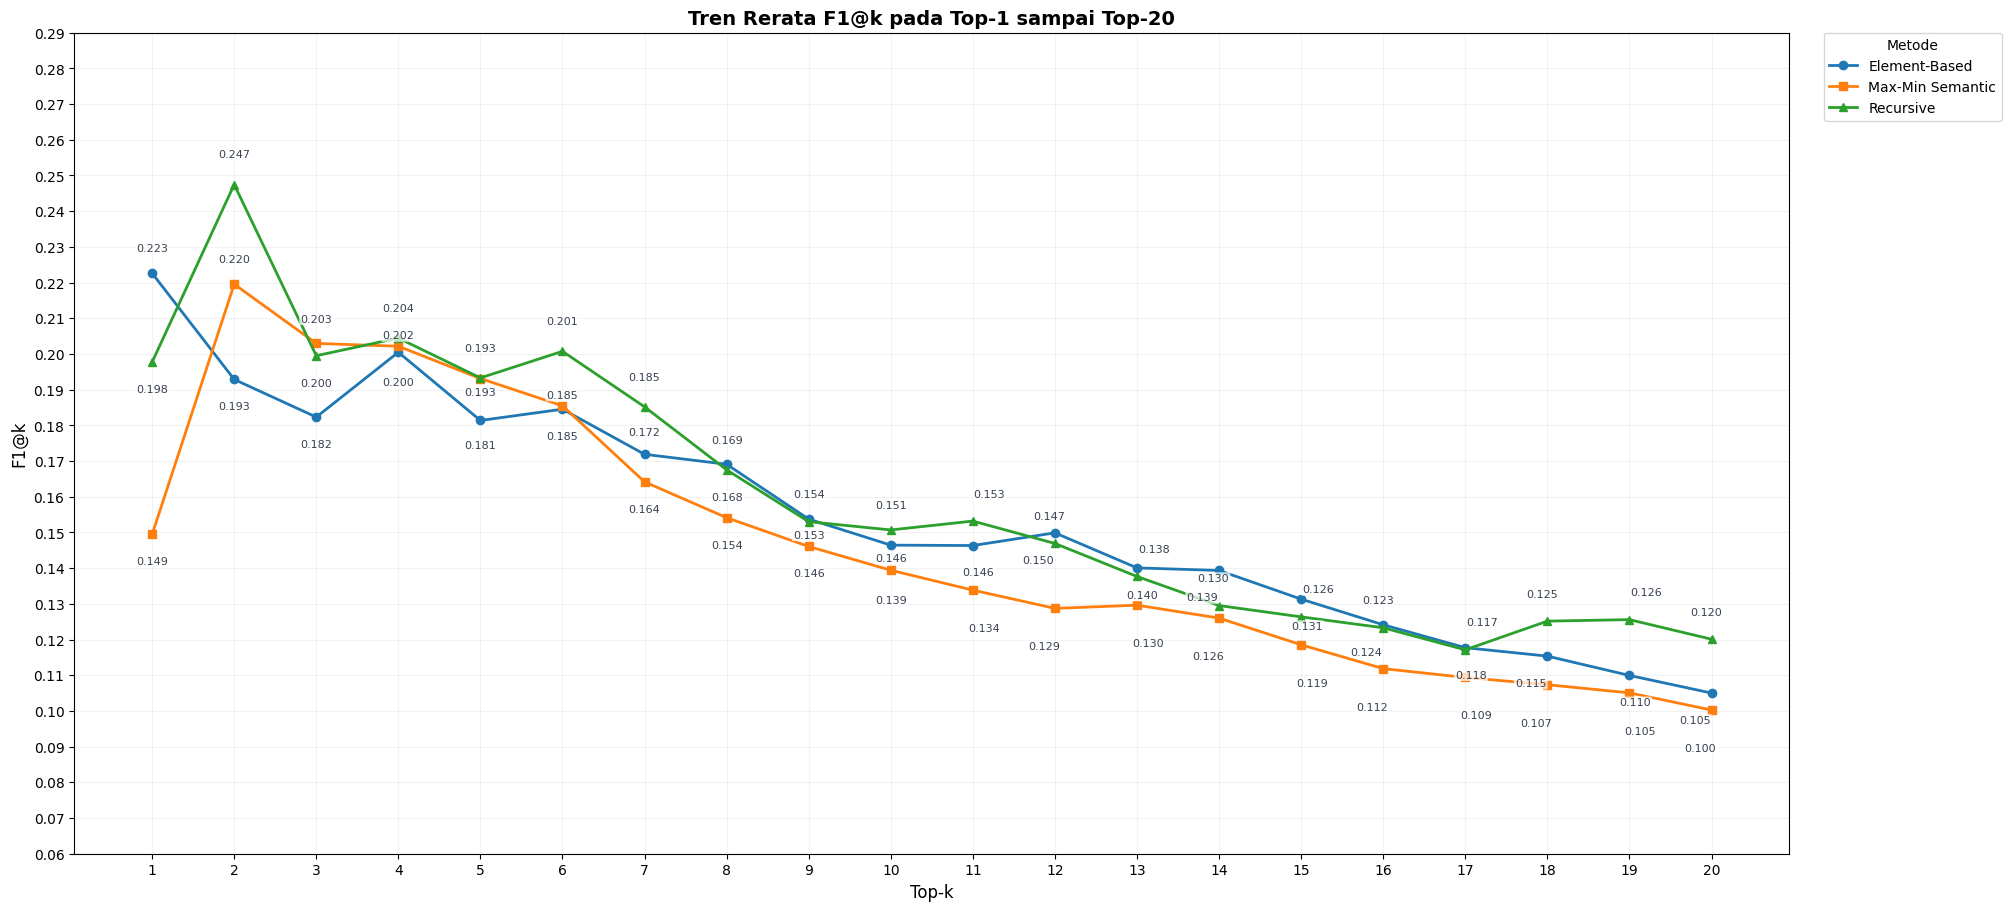

Chart 4 saved

Tabel 4: F1@k per Metode dan Top-k


Method,Element,MaxMin,Recursive
Top-k,,,
1,0.2226,0.1494,0.1977
2,0.1929,0.2195,0.2475
3,0.1823,0.2030,0.1995
4,0.2005,0.2022,0.2044
5,0.1814,0.1931,0.1933
6,0.1845,0.1855,0.2007
7,0.1719,0.1642,0.1852
8,0.1691,0.1541,0.1675
9,0.1537,0.1461,0.1530


Table 4 exported


In [54]:
# Chart 4 + Tabel 4: F1@k trend (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(20, 9), constrained_layout=True)
method_display_labels = {
    'Element': 'Element-Based',
    'MaxMin': 'Max-Min Semantic',
    'Recursive': 'Recursive',
}
method_line_styles = {
    'Element': {'marker': 'o', 'linestyle': '-'},
    'MaxMin': {'marker': 's', 'linestyle': '-'},
    'Recursive': {'marker': '^', 'linestyle': '-'},
}
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    style = method_line_styles[method]
    ax.plot(
        subset['top_k'],
        subset['f1_at_k'],
        marker=style['marker'],
        linestyle=style['linestyle'],
        label=method_display_labels[method],
        linewidth=2,
        markersize=6,
    )

f1_label_offsets = {
    ('Element', 1): (0, 14),
    ('MaxMin', 1): (0, -16),
    ('Recursive', 1): (0, -16),
    ('Element', 2): (0, -16),
    ('MaxMin', 2): (0, 14),
    ('Recursive', 2): (0, 18),
    ('Element', 3): (0, -16),
    ('MaxMin', 3): (0, 14),
    ('Recursive', 3): (0, -16),
    ('Element', 4): (0, -18),
    ('MaxMin', 4): (0, 4),
    ('Recursive', 4): (0, 18),
    ('Element', 5): (0, -14),
    ('MaxMin', 5): (0, -6),
    ('Recursive', 5): (0, 18),
    ('Element', 6): (0, -16),
    ('MaxMin', 6): (0, 4),
    ('Recursive', 6): (0, 18),
    ('Element', 7): (0, 12),
    ('MaxMin', 7): (0, -16),
    ('Recursive', 7): (0, 18),
    ('Element', 8): (0, 14),
    ('MaxMin', 8): (0, -16),
    ('Recursive', 8): (0, -16),
    ('Element', 9): (0, 14),
    ('MaxMin', 9): (0, -16),
    ('Recursive', 9): (0, -6),
    ('Element', 10): (0, -6),
    ('MaxMin', 10): (0, -18),
    ('Recursive', 10): (0, 14),
}
for _, row in trend.iterrows():
    if not should_label_topk(row['top_k']):
        continue
    x_offset, y_offset = resolve_label_offset(
        f1_label_offsets,
        row['method_short'],
        row['top_k'],
        (0, 12),
        'f1'
    )
    ax.annotate(
        f"{row['f1_at_k']:.3f}",
        (row['top_k'], row['f1_at_k']),
        textcoords='offset points',
        xytext=(x_offset, y_offset),
        ha='center',
        va='bottom' if y_offset >= 0 else 'top',
        fontsize=8,
        color='#374151',
        bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.72)
    )

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('F1@k', fontsize=12)
ax.set_title('Tren Rerata F1@k pada Top-1 sampai Top-20', fontsize=14, fontweight='bold')
ax.legend(title='Metode', fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.minorticks_off()
ax.grid(True, which='major', axis='both', alpha=0.16, linewidth=0.8)
ax.set_xticks(range(TOPK_MIN, TOPK_MAX + 1))
pad_y_axis(ax, trend['f1_at_k'], pad_ratio=0.25)
f1_y_top = np.ceil(ax.get_ylim()[1] * 100) / 100
f1_y_bottom = np.floor(ax.get_ylim()[0] * 100) / 100
f1_yticks = np.round(np.arange(f1_y_bottom, f1_y_top + 0.001, 0.01), 2)
ax.set_yticks(f1_yticks)
ax.set_yticklabels([f'{tick:.2f}' for tick in f1_yticks])

plt.savefig(FIG_DIR / 'chart4_f1_trend.png', dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()
print('Chart 4 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table4 = (
    trend.pivot(index='top_k', columns='method_short', values='f1_at_k')
    .rename_axis(index='Top-k', columns='Method')
)
print('\nTabel 4: F1@k per Metode dan Top-k')
styled_table4 = format_metric_table(table4, axis=1)
display(styled_table4)

# Export CSV
table4.to_csv(FIG_DIR / 'table4_f1_trend.csv')
print('Table 4 exported')


## Chart 5: BLEU per Metode dan Top-k (Top-1 hingga Top-20)

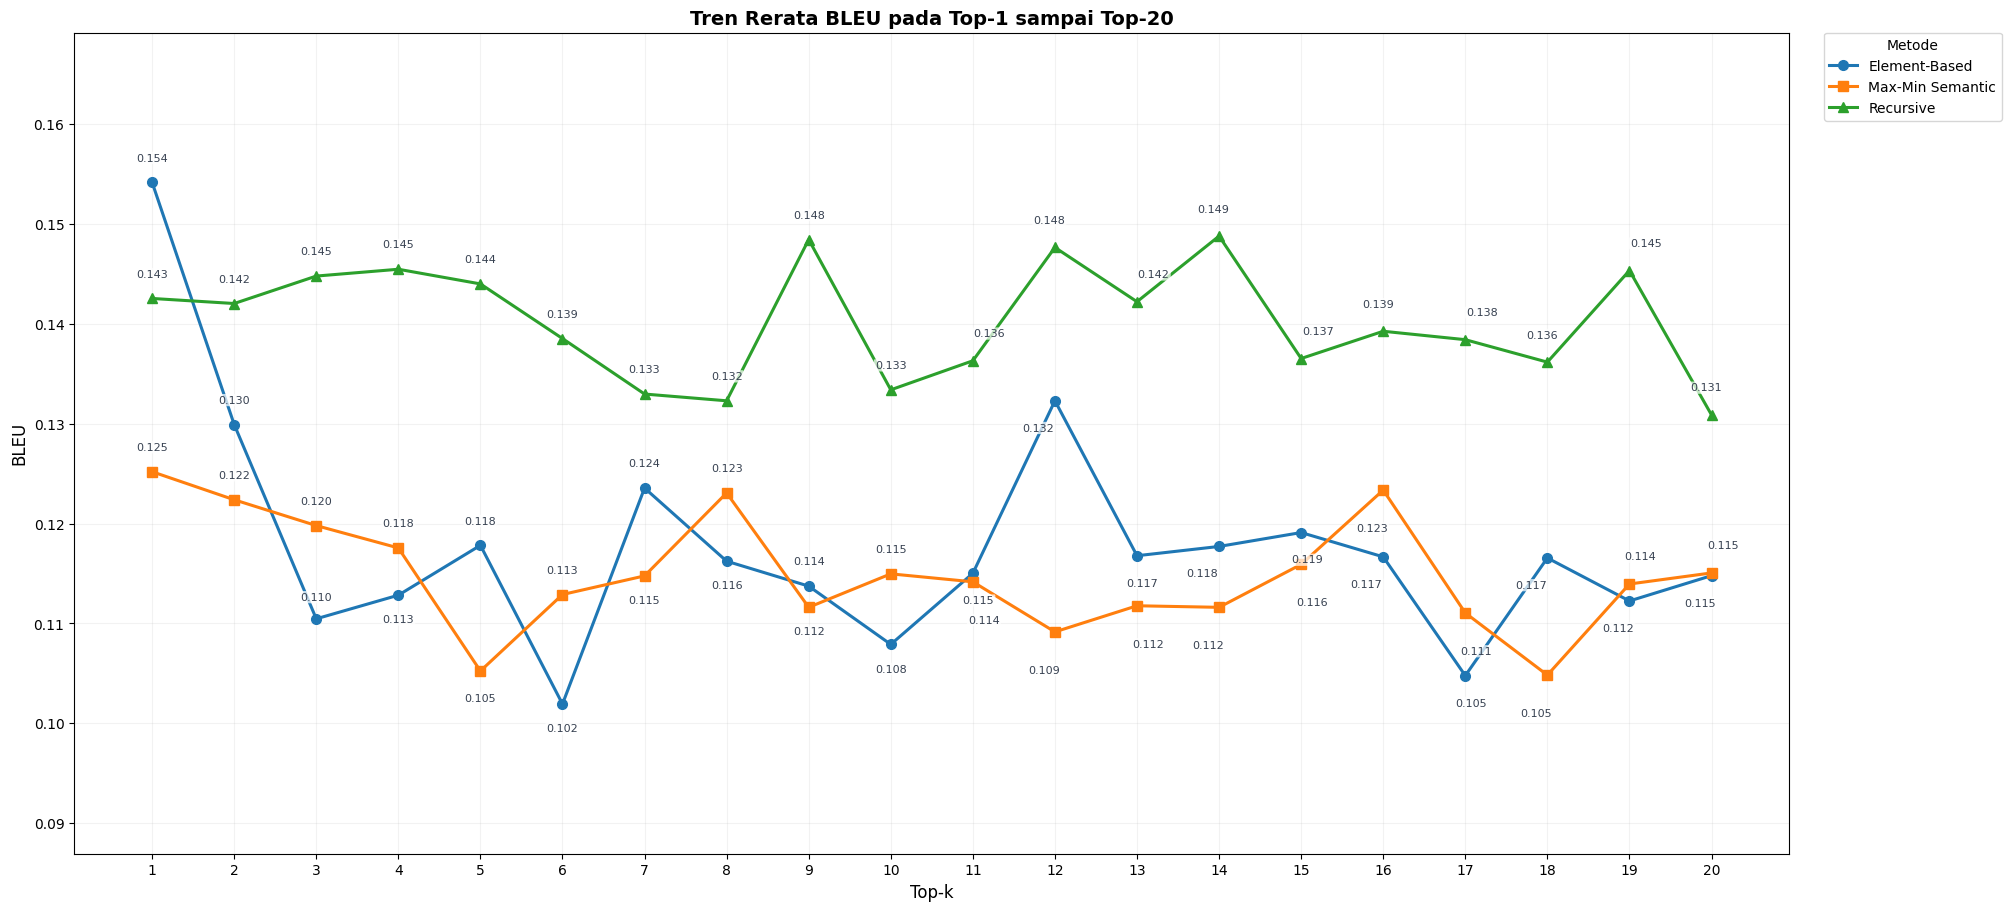

Chart 5 saved

Tabel 5: Global Average BLEU per Metode dan Top-k (Top-1 hingga Top-20)


Method,Element,MaxMin,Recursive
Top-k,,,
1,0.1542,0.1252,0.1426
2,0.1299,0.1224,0.1420
3,0.1105,0.1198,0.1448
4,0.1128,0.1176,0.1455
5,0.1178,0.1052,0.1440
6,0.1019,0.1129,0.1385
7,0.1236,0.1148,0.1330
8,0.1162,0.1231,0.1323
9,0.1137,0.1116,0.1485


Table 5 exported


In [55]:
# Chart 5 + Tabel 5: BLEU per Top-k (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(20, 9), constrained_layout=True)
color_map = {'Element': '#1f77b4', 'MaxMin': '#ff7f0e', 'Recursive': '#2ca02c'}
method_display_labels = {
    'Element': 'Element-Based',
    'MaxMin': 'Max-Min Semantic',
    'Recursive': 'Recursive',
}
method_line_styles = {
    'Element': {'marker': 'o', 'linestyle': '-'},
    'MaxMin': {'marker': 's', 'linestyle': '-'},
    'Recursive': {'marker': '^', 'linestyle': '-'},
}
bleu_label_offsets = {
    ('Element', 1): (0, 14),
    ('MaxMin', 1): (0, 14),
    ('Recursive', 1): (0, 14),
    ('Element', 2): (0, 14),
    ('MaxMin', 2): (0, 14),
    ('Recursive', 2): (0, 14),
    ('Element', 3): (0, 12),
    ('MaxMin', 3): (0, 14),
    ('Recursive', 3): (0, 14),
    ('Element', 4): (0, -14),
    ('MaxMin', 4): (0, 14),
    ('Recursive', 4): (0, 14),
    ('Element', 5): (0, 14),
    ('MaxMin', 5): (0, -16),
    ('Recursive', 5): (0, 14),
    ('Element', 6): (0, -14),
    ('MaxMin', 6): (0, 14),
    ('Recursive', 6): (0, 14),
    ('Element', 7): (0, 14),
    ('MaxMin', 7): (0, -14),
    ('Recursive', 7): (0, 14),
    ('Element', 8): (0, -14),
    ('MaxMin', 8): (0, 14),
    ('Recursive', 8): (0, 14),
    ('Element', 9): (0, 14),
    ('MaxMin', 9): (0, -14),
    ('Recursive', 9): (0, 14),
    ('Element', 10): (0, -14),
    ('MaxMin', 10): (0, 14),
    ('Recursive', 10): (0, 14),
    ('Element', 19): (-8, -16),
    ('MaxMin', 19): (8, 16),
    ('Element', 20): (-8, -16),
    ('MaxMin', 20): (8, 16),
}

for method in ['Element', 'MaxMin', 'Recursive']:
    subset = gen_avg[gen_avg['method_short'] == method].sort_values('top_k')
    style = method_line_styles[method]
    ax.plot(
        subset['top_k'],
        subset['bleu'],
        marker=style['marker'],
        linestyle=style['linestyle'],
        linewidth=2.2,
        markersize=7,
        label=method_display_labels[method],
        color=color_map[method]
    )
    for _, row in subset.iterrows():
        if not should_label_topk(row['top_k']):
            continue
        x_offset, y_offset = resolve_label_offset(
            bleu_label_offsets,
            method,
            row['top_k'],
            (0, 10),
            'bleu'
        )
        valign = 'bottom' if y_offset >= 0 else 'top'
        ax.annotate(
            f"{row['bleu']:.3f}",
            (row['top_k'], row['bleu']),
            textcoords='offset points',
            xytext=(x_offset, y_offset),
            ha='center',
            va=valign,
            fontsize=8,
            color='#374151',
            bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.72)
        )

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('BLEU', fontsize=12)
ax.set_title(f'Tren Rerata BLEU pada Top-{TOPK_MIN} sampai Top-{TOPK_MAX}', fontsize=14, fontweight='bold')
ax.set_xticks(list(range(TOPK_MIN, TOPK_MAX + 1)))
ax.legend(title='Metode', fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.minorticks_off()
ax.grid(True, which='major', axis='both', alpha=0.16, linewidth=0.8)
pad_y_axis(ax, gen_avg['bleu'], pad_ratio=0.25)

plt.savefig(FIG_DIR / 'chart5_bleu_topk.png', dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()
print('Chart 5 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table5 = (
    gen_avg.pivot(index='top_k', columns='method_short', values='bleu')
    .rename_axis(index='Top-k', columns='Method')
)
print()
print(f'Tabel 5: Global Average BLEU per Metode dan Top-k (Top-{TOPK_MIN} hingga Top-{TOPK_MAX})')
styled_table5 = format_metric_table(table5, axis=1)
display(styled_table5)

# Export CSV
table5.to_csv(FIG_DIR / 'table5_bleu_topk.csv')
print('Table 5 exported')

## Chart 6: ROUGE-L per Metode dan Top-k (Top-1 hingga Top-20)

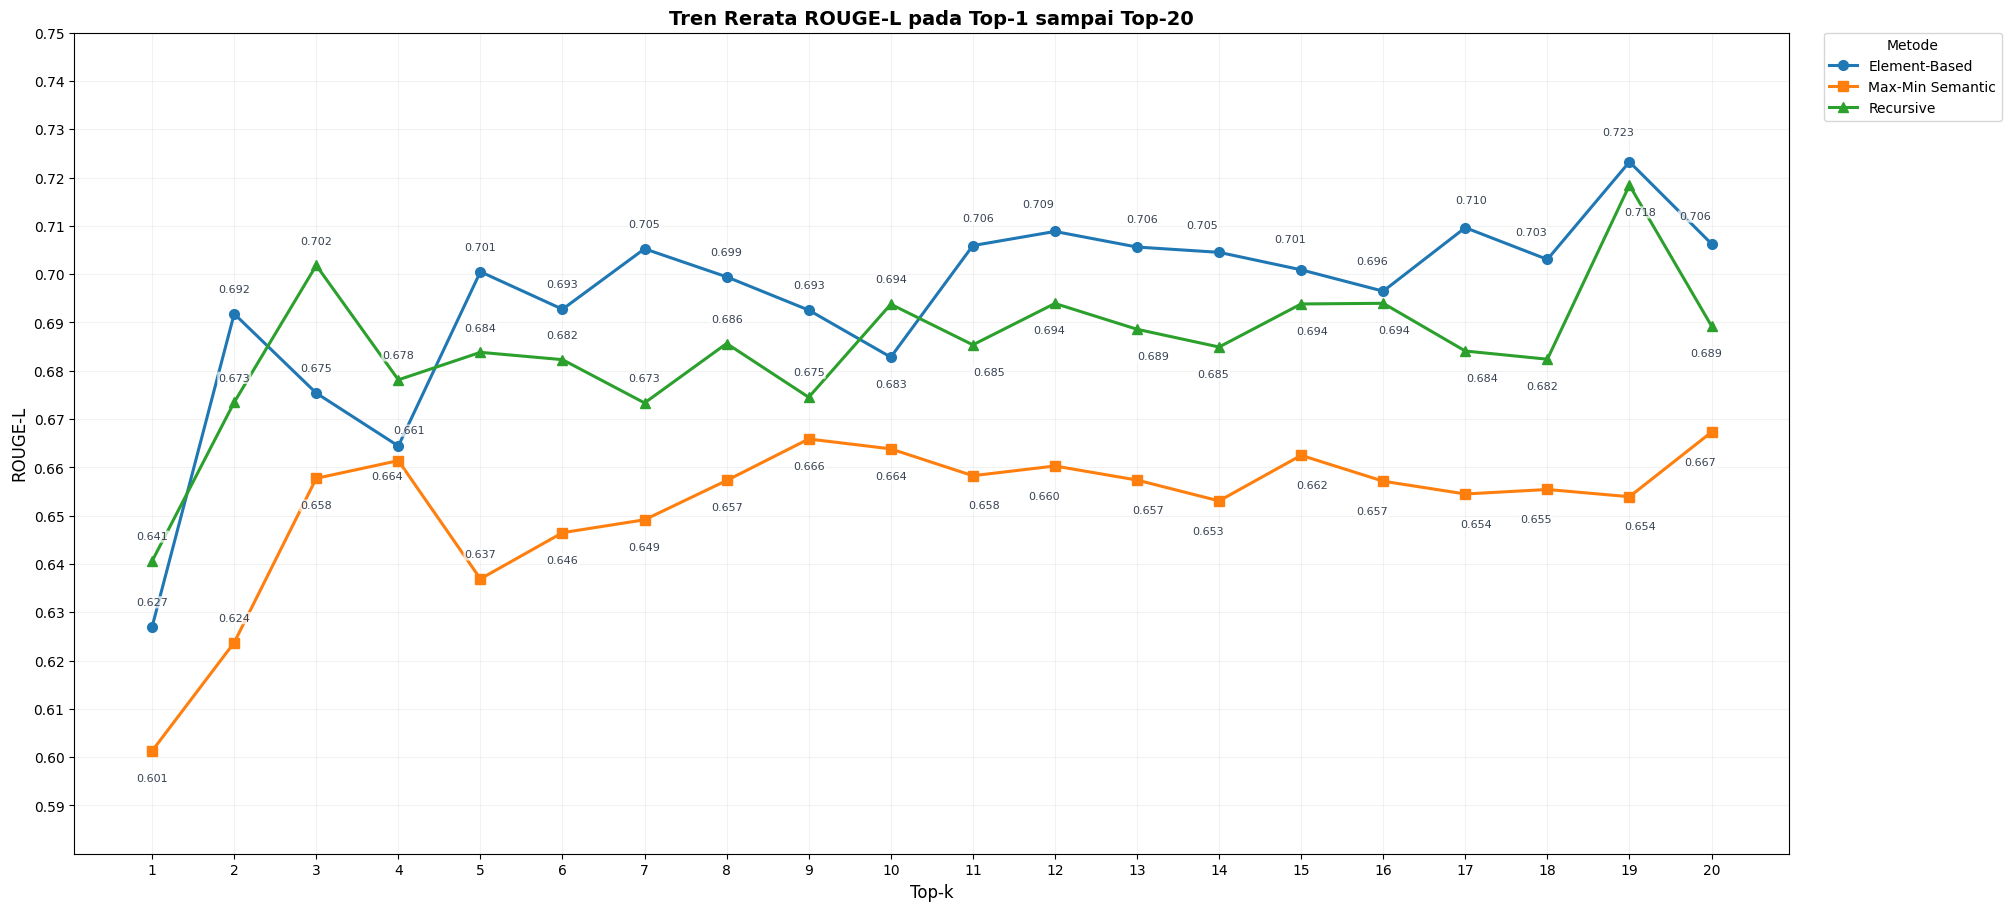

Chart 6 saved

Tabel 6: Global Average ROUGE-L per Metode dan Top-k (Top-1 hingga Top-20)


Method,Element,MaxMin,Recursive
Top-k,,,
1,0.6270,0.6013,0.6406
2,0.6918,0.6237,0.6735
3,0.6754,0.6577,0.7018
4,0.6644,0.6614,0.6781
5,0.7005,0.6369,0.6838
6,0.6927,0.6465,0.6823
7,0.7053,0.6491,0.6733
8,0.6994,0.6573,0.6856
9,0.6926,0.6659,0.6745


Table 6 exported


In [56]:
# Chart 6 + Tabel 6: ROUGE-L per Top-k (DALAM SATU CELL)

# === CHART ===
fig, ax = plt.subplots(figsize=(20, 9), constrained_layout=True)
color_map = {'Element': '#1f77b4', 'MaxMin': '#ff7f0e', 'Recursive': '#2ca02c'}
method_display_labels = {
    'Element': 'Element-Based',
    'MaxMin': 'Max-Min Semantic',
    'Recursive': 'Recursive',
}
method_line_styles = {
    'Element': {'marker': 'o', 'linestyle': '-'},
    'MaxMin': {'marker': 's', 'linestyle': '-'},
    'Recursive': {'marker': '^', 'linestyle': '-'},
}
rouge_label_offsets = {
    ('Element', 1): (0, 14),
    ('MaxMin', 1): (0, -16),
    ('Recursive', 1): (0, 14),
    ('Element', 2): (0, 14),
    ('MaxMin', 2): (0, 14),
    ('Recursive', 2): (0, 14),
    ('Element', 3): (0, 14),
    ('MaxMin', 3): (0, -16),
    ('Recursive', 3): (0, 14),
    ('Element', 4): (0, -16),
    ('MaxMin', 4): (0, 14),
    ('Recursive', 4): (0, 14),
    ('Element', 5): (0, 14),
    ('MaxMin', 5): (0, 14),
    ('Recursive', 5): (0, 14),
    ('Element', 6): (0, 14),
    ('MaxMin', 6): (0, -16),
    ('Recursive', 6): (0, 14),
    ('Element', 7): (0, 14),
    ('MaxMin', 7): (0, -16),
    ('Recursive', 7): (0, 14),
    ('Element', 8): (0, 14),
    ('MaxMin', 8): (0, -16),
    ('Recursive', 8): (0, 14),
    ('Element', 9): (0, 14),
    ('MaxMin', 9): (0, -16),
    ('Recursive', 9): (0, 14),
    ('Element', 10): (0, -16),
    ('MaxMin', 10): (0, -16),
    ('Recursive', 10): (0, 14),
    ('Element', 4): (-8, -18),
    ('MaxMin', 4): (8, 18),
    ('Element', 15): (-8, 18),
    ('Recursive', 15): (8, -16),
    ('Element', 16): (-8, 18),
    ('Recursive', 16): (8, -16),
    ('Element', 19): (-8, 18),
    ('Recursive', 19): (8, -16),
}

for method in ['Element', 'MaxMin', 'Recursive']:
    subset = gen_avg[gen_avg['method_short'] == method].sort_values('top_k')
    style = method_line_styles[method]
    ax.plot(
        subset['top_k'],
        subset['rouge_l'],
        marker=style['marker'],
        linestyle=style['linestyle'],
        linewidth=2.2,
        markersize=7,
        label=method_display_labels[method],
        color=color_map[method]
    )
    for _, row in subset.iterrows():
        if not should_label_topk(row['top_k']):
            continue
        x_offset, y_offset = resolve_label_offset(
            rouge_label_offsets,
            method,
            row['top_k'],
            (0, 10),
            'rouge'
        )
        valign = 'bottom' if y_offset >= 0 else 'top'
        ax.annotate(
            f"{row['rouge_l']:.3f}",
            (row['top_k'], row['rouge_l']),
            textcoords='offset points',
            xytext=(x_offset, y_offset),
            ha='center',
            va=valign,
            fontsize=8,
            color='#374151',
            bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.72)
        )

ax.set_xlabel('Top-k', fontsize=12)
ax.set_ylabel('ROUGE-L', fontsize=12)
ax.set_title(f'Tren Rerata ROUGE-L pada Top-{TOPK_MIN} sampai Top-{TOPK_MAX}', fontsize=14, fontweight='bold')
ax.set_xticks(list(range(TOPK_MIN, TOPK_MAX + 1)))
ax.legend(title='Metode', fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.minorticks_off()
ax.grid(True, which='major', axis='both', alpha=0.16, linewidth=0.8)
rouge_y_bottom = np.floor((gen_avg['rouge_l'].min() - 0.02) * 100) / 100
rouge_y_top = np.ceil((gen_avg['rouge_l'].max() + 0.02) * 100) / 100
rouge_yticks = np.round(np.arange(rouge_y_bottom + 0.01, rouge_y_top + 0.001, 0.01), 2)
ax.set_ylim(rouge_y_bottom, rouge_y_top)
ax.set_yticks(rouge_yticks)
ax.set_yticklabels([f'{tick:.2f}' for tick in rouge_yticks])

plt.savefig(FIG_DIR / 'chart6_rouge_l_topk.png', dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()
print('Chart 6 saved')

# === TABEL (TEPAT DI BAWAH CHART) ===
table6 = (
    gen_avg.pivot(index='top_k', columns='method_short', values='rouge_l')
    .rename_axis(index='Top-k', columns='Method')
)
print()
print(f'Tabel 6: Global Average ROUGE-L per Metode dan Top-k (Top-{TOPK_MIN} hingga Top-{TOPK_MAX})')
styled_table6 = format_metric_table(table6, axis=1)
display(styled_table6)

# Export CSV
table6.to_csv(FIG_DIR / 'table6_rouge_l_topk.csv')
print('Table 6 exported')

## Chart 7: Distribusi Tipe Evidence pada Ground Truth

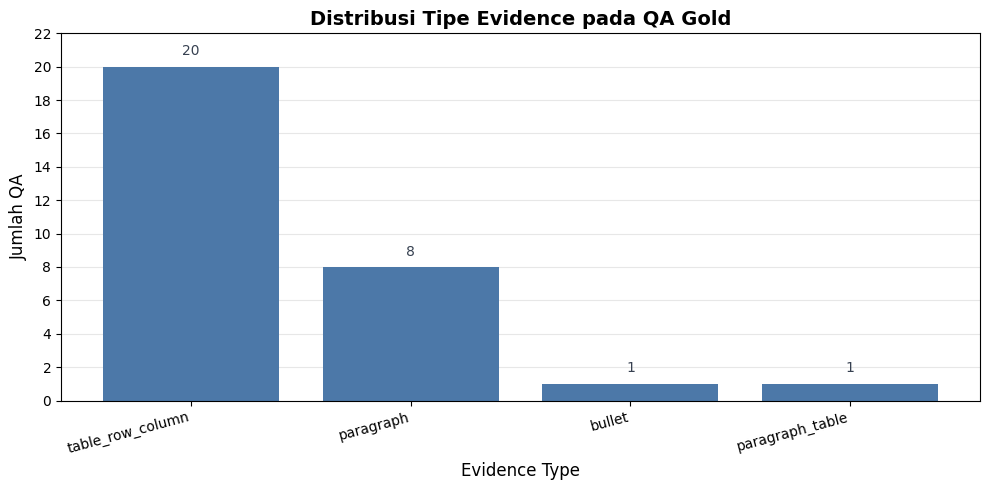

Chart 7 saved

Tabel 7: Distribusi Tipe Evidence pada QA Gold


Evidence Type,Count
table_row_column,20
paragraph,8
bullet,1
paragraph_table,1


Table 7 exported


In [57]:
# Chart 7 + Tabel 7: Distribusi tipe evidence pada QA gold

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(qa_evidence_counts['Evidence Type'], qa_evidence_counts['Count'], color='#4c78a8')

ax.set_xlabel('Evidence Type', fontsize=12)
ax.set_ylabel('Jumlah QA', fontsize=12)
ax.set_title('Distribusi Tipe Evidence pada QA Gold', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, 22)
ax.set_yticks(range(0, 23, 2))
plt.xticks(rotation=15, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        textcoords='offset points',
        xytext=(0, 6),
        ha='center',
        va='bottom',
        fontsize=10,
        color='#374151'
    )

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart7_ground_truth_evidence_types.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 7 saved')

table9 = qa_evidence_counts.set_index('Evidence Type')
print('\nTabel 7: Distribusi Tipe Evidence pada QA Gold')
table9_display = table9.reset_index()
styled_table9 = (
    table9_display.style
    .format({'Count': '{:.0f}'})
    .apply(highlight_max_only, subset=['Count'], axis=0)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
    ])
    .hide(axis='index')
)
display(styled_table9)
table9.to_csv(FIG_DIR / 'table7_ground_truth_evidence_types.csv')
print('Table 7 exported')

## Chart 8: Distribusi Label Relevansi Ground Truth Retrieval

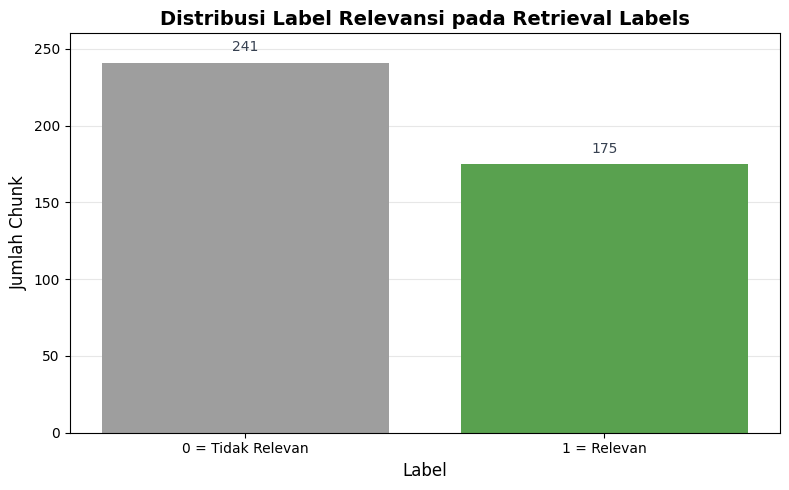

Chart 8 saved

Tabel 8: Distribusi Label Relevansi Retrieval


Label,Count
0 = Tidak Relevan,241
1 = Relevan,175


Table 8 exported


In [58]:
# Chart 8 + Tabel 8: Distribusi label relevansi retrieval labels

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(label_counts['Label Name'], label_counts['Count'], color=['#9e9e9e', '#59a14f'][:len(label_counts)])

ax.set_xlabel('Label', fontsize=12)
ax.set_ylabel('Jumlah Chunk', fontsize=12)
ax.set_title('Distribusi Label Relevansi pada Retrieval Labels', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.set_ylim(0, 260)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        textcoords='offset points',
        xytext=(0, 6),
        ha='center',
        va='bottom',
        fontsize=10,
        color='#374151'
    )

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart8_ground_truth_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart 8 saved')

table8 = label_counts[['Label Name', 'Count']].rename(columns={'Label Name': 'Label'}).set_index('Label')
print('\nTabel 8: Distribusi Label Relevansi Retrieval')
table8_display = table8.reset_index()
styled_table8 = (
    table8_display.style
    .format({'Count': '{:.0f}'})
    .apply(highlight_max_only, subset=['Count'], axis=0)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
    ])
    .hide(axis='index')
)
display(styled_table8)
table8.to_csv(FIG_DIR / 'table8_ground_truth_label_distribution.csv')
print('Table 8 exported')

### Tabel 6.1 Ringkasan Hasil Evaluasi Retrieval pada Top-1 sampai Top-20

In [59]:
# Tabel 6.1: Ringkasan agregat evaluasi retrieval untuk Bab 6
from pathlib import Path

method_display_order = [
    'Element-Based Chunking',
    'Max-Min Semantic Chunking',
    'Recursive Chunking',
]
method_display_map = {
    'Element': 'Element-Based Chunking',
    'MaxMin': 'Max-Min Semantic Chunking',
    'Recursive': 'Recursive Chunking',
    'element_based': 'Element-Based Chunking',
    'maxmin_semantic': 'Max-Min Semantic Chunking',
    'recursive': 'Recursive Chunking',
}

if 'trend' in globals():
    retrieval_summary_source = trend.copy()
else:
    final_eval_dir = Path('../results/final/generation')
    retrieval_frames = []
    for k in range(TOPK_MIN, TOPK_MAX + 1):
        matches = sorted(final_eval_dir.glob(f'eval_*_top{k}.csv'))
        if not matches:
            raise FileNotFoundError(
                f'File evaluasi final untuk top-{k} tidak ditemukan di {final_eval_dir}'
            )
        df_k = pd.read_csv(matches[-1])
        df_k['top_k'] = k
        retrieval_frames.append(df_k)
    retrieval_summary_source = pd.concat(retrieval_frames, ignore_index=True)
    if 'method_short' not in retrieval_summary_source.columns:
        retrieval_summary_source['method_short'] = retrieval_summary_source['method'].map({
            'element_based': 'Element',
            'maxmin_semantic': 'MaxMin',
            'recursive': 'Recursive',
        }).fillna(retrieval_summary_source['method'])
    retrieval_summary_source = (
        retrieval_summary_source
        .groupby(['top_k', 'method_short'])[['precision_at_k', 'recall_at_k', 'mrr', 'f1_at_k']]
        .mean()
        .reset_index()
    )

table_6_1_retrieval_summary = retrieval_summary_source[
    ['top_k', 'method_short', 'precision_at_k', 'recall_at_k', 'mrr', 'f1_at_k']
].copy()
table_6_1_retrieval_summary['Metode Chunking'] = table_6_1_retrieval_summary['method_short'].map(method_display_map)
table_6_1_retrieval_summary = table_6_1_retrieval_summary.rename(columns={
    'top_k': 'Top-k',
    'precision_at_k': 'Precision@k',
    'recall_at_k': 'Recall@k',
    'mrr': 'MRR',
    'f1_at_k': 'F1@k',
})
table_6_1_retrieval_summary = table_6_1_retrieval_summary[
    ['Metode Chunking', 'Top-k', 'Precision@k', 'Recall@k', 'MRR', 'F1@k']
]
table_6_1_retrieval_summary['Metode Chunking'] = pd.Categorical(
    table_6_1_retrieval_summary['Metode Chunking'],
    categories=method_display_order,
    ordered=True,
)
table_6_1_retrieval_summary = (
    table_6_1_retrieval_summary
    .sort_values(['Metode Chunking', 'Top-k'])
    .reset_index(drop=True)
)
table_6_1_retrieval_summary['Metode Chunking'] = table_6_1_retrieval_summary['Metode Chunking'].astype(str)
metric_columns = ['Precision@k', 'Recall@k', 'MRR', 'F1@k']
table_6_1_retrieval_summary[metric_columns] = table_6_1_retrieval_summary[metric_columns].round(3)

expected_topk = set(range(TOPK_MIN, TOPK_MAX + 1))
expected_row_count = len(method_display_order) * len(expected_topk)
expected_topk_count = len(expected_topk)
actual_topk = set(table_6_1_retrieval_summary['Top-k'].dropna().astype(int))
rows_per_method = table_6_1_retrieval_summary.groupby('Metode Chunking')['Top-k'].nunique()

validation_errors = []
if len(table_6_1_retrieval_summary) != expected_row_count:
    validation_errors.append(f'Jumlah baris harus {expected_row_count}, ditemukan {len(table_6_1_retrieval_summary)}.')
if actual_topk != expected_topk:
    validation_errors.append(f'Top-k harus hanya {sorted(expected_topk)}, ditemukan {sorted(actual_topk)}.')
invalid_method_counts = rows_per_method[rows_per_method != expected_topk_count]
if not invalid_method_counts.empty:
    validation_errors.append(f'Setiap metode harus memiliki Top-k {TOPK_MIN} sampai {TOPK_MAX}; detail: {invalid_method_counts.to_dict()}.')
if table_6_1_retrieval_summary[metric_columns].isna().any().any():
    null_cols = table_6_1_retrieval_summary[metric_columns].columns[
        table_6_1_retrieval_summary[metric_columns].isna().any()
    ].tolist()
    validation_errors.append(f'Kolom metrik tidak boleh NaN; kolom bermasalah: {null_cols}.')
if table_6_1_retrieval_summary['Metode Chunking'].isna().any() or (table_6_1_retrieval_summary['Metode Chunking'] == 'nan').any():
    validation_errors.append('Ada metode chunking yang tidak dikenali pada tabel ringkasan retrieval.')

if validation_errors:
    raise ValueError('Validasi Tabel 6.1 gagal:\n- ' + '\n- '.join(validation_errors))

display(table_6_1_retrieval_summary.style.hide(axis='index').format({col: '{:.3f}' for col in metric_columns}))

table_output_dir = FIG_DIR
table_output_dir.mkdir(parents=True, exist_ok=True)
table_6_1_retrieval_summary.to_csv(table_output_dir / 'table_6_1_retrieval_summary.csv', index=False, float_format='%.3f')
xlsx_output_path = table_output_dir / 'table_6_1_retrieval_summary.xlsx'
table_6_1_retrieval_summary.to_excel(xlsx_output_path, index=False)

try:
    from openpyxl import load_workbook
    wb = load_workbook(xlsx_output_path)
    ws = wb.active
    for start_row in range(2, 2 + expected_row_count, expected_topk_count):
        ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row + expected_topk_count - 1, end_column=1)
    for row in ws.iter_rows(min_row=2, min_col=3, max_col=5):
        for cell in row:
            cell.number_format = '0.000'
    ws.column_dimensions.group('F', 'XFD', hidden=True)
    wb.save(xlsx_output_path)
except ImportError:
    pass
print('Tabel 6.1 exported')

Metode Chunking,Top-k,Precision@k,Recall@k,MRR,F1@k
Element-Based Chunking,1,0.286,0.199,0.286,0.223
Element-Based Chunking,2,0.179,0.244,0.304,0.193
Element-Based Chunking,3,0.143,0.298,0.327,0.182
Element-Based Chunking,4,0.152,0.374,0.354,0.200
Element-Based Chunking,5,0.129,0.392,0.354,0.181
Element-Based Chunking,6,0.125,0.452,0.366,0.185
Element-Based Chunking,7,0.112,0.470,0.366,0.172
Element-Based Chunking,8,0.107,0.517,0.375,0.169
Element-Based Chunking,9,0.095,0.517,0.375,0.154
Element-Based Chunking,10,0.089,0.529,0.379,0.146


Tabel 6.1 exported


### Tabel 6.2 Ringkasan Rerata Hasil Evaluasi Generation pada Top-1 sampai Top-20

In [60]:
# Tabel 6.2: Ringkasan rerata evaluasi generation untuk Bab 6
from pathlib import Path

method_display_order = [
    'Element-Based Chunking',
    'Max-Min Semantic Chunking',
    'Recursive Chunking',
]
method_display_map = {
    'Element': 'Element-Based Chunking',
    'MaxMin': 'Max-Min Semantic Chunking',
    'Recursive': 'Recursive Chunking',
    'element_based': 'Element-Based Chunking',
    'maxmin_semantic': 'Max-Min Semantic Chunking',
    'recursive': 'Recursive Chunking',
    'Element-Based': 'Element-Based Chunking',
    'MaxMin Semantic': 'Max-Min Semantic Chunking',
}

if 'gen_avg' in globals():
    generation_summary_source = gen_avg.copy()
else:
    final_eval_dir = Path('../results/final/generation')
    generation_frames = []
    for k in range(TOPK_MIN, TOPK_MAX + 1):
        matches = sorted(final_eval_dir.glob(f'eval_*_top{k}.csv'))
        if not matches:
            raise FileNotFoundError(f'File evaluasi generation final untuk Top-{k} tidak ditemukan di {final_eval_dir}.')
        df_k = pd.read_csv(matches[-1])
        df_k['top_k'] = k
        generation_frames.append(df_k)

    generation_summary_source = pd.concat(generation_frames, ignore_index=True)
    if 'method_short' not in generation_summary_source.columns:
        generation_summary_source['method_short'] = generation_summary_source['method'].map({
            'element_based': 'Element',
            'maxmin_semantic': 'MaxMin',
            'recursive': 'Recursive',
            'Element-Based': 'Element',
            'MaxMin Semantic': 'MaxMin',
        }).fillna(generation_summary_source['method'])
    if 'rouge_l' not in generation_summary_source.columns:
        generation_summary_source = generation_summary_source.rename(columns={'rouge_l_recall': 'rouge_l'})
    generation_summary_source = (
        generation_summary_source
        .groupby(['top_k', 'method_short'])[['bleu', 'rouge_l']]
        .mean()
        .reset_index()
    )

table_6_2_generation_summary = generation_summary_source[
    ['top_k', 'method_short', 'bleu', 'rouge_l']
].copy()
table_6_2_generation_summary['Metode Chunking'] = table_6_2_generation_summary['method_short'].map(method_display_map)
table_6_2_generation_summary = table_6_2_generation_summary.rename(columns={
    'top_k': 'Top-k',
    'bleu': 'BLEU',
    'rouge_l': 'ROUGE-L',
})
table_6_2_generation_summary = table_6_2_generation_summary[
    ['Metode Chunking', 'Top-k', 'BLEU', 'ROUGE-L']
]
table_6_2_generation_summary['Metode Chunking'] = pd.Categorical(
    table_6_2_generation_summary['Metode Chunking'],
    categories=method_display_order,
    ordered=True,
)
table_6_2_generation_summary = (
    table_6_2_generation_summary
    .sort_values(['Metode Chunking', 'Top-k'])
    .reset_index(drop=True)
)
table_6_2_generation_summary['Metode Chunking'] = table_6_2_generation_summary['Metode Chunking'].astype(str)

metric_columns = ['BLEU', 'ROUGE-L']
table_6_2_generation_summary[metric_columns] = table_6_2_generation_summary[metric_columns].round(3)

expected_topk = set(range(TOPK_MIN, TOPK_MAX + 1))
expected_row_count = len(method_display_order) * len(expected_topk)
expected_topk_count = len(expected_topk)
actual_topk = set(table_6_2_generation_summary['Top-k'].dropna().astype(int))
rows_per_method = table_6_2_generation_summary.groupby('Metode Chunking')['Top-k'].nunique()
validation_errors = []

if len(table_6_2_generation_summary) != expected_row_count:
    validation_errors.append(f'Jumlah baris harus {expected_row_count}, ditemukan {len(table_6_2_generation_summary)}.')
if actual_topk != expected_topk:
    validation_errors.append(f'Top-k harus {sorted(expected_topk)}, ditemukan {sorted(actual_topk)}.')
if not rows_per_method.reindex(method_display_order).eq(expected_topk_count).all():
    validation_errors.append(f'Setiap metode harus memiliki Top-k {TOPK_MIN} sampai {TOPK_MAX}.')
if table_6_2_generation_summary[metric_columns].isna().any().any():
    null_cols = table_6_2_generation_summary[metric_columns].columns[
        table_6_2_generation_summary[metric_columns].isna().any()
    ].tolist()
    validation_errors.append(f'Kolom metrik tidak boleh NaN: {null_cols}.')
if table_6_2_generation_summary['Metode Chunking'].isna().any() or (table_6_2_generation_summary['Metode Chunking'] == 'nan').any():
    validation_errors.append('Ada method yang belum berhasil dipetakan ke nama Metode Chunking.')

if validation_errors:
    raise ValueError('Validasi Tabel 6.2 gagal:\n- ' + '\n- '.join(validation_errors))

display(table_6_2_generation_summary.style.hide(axis='index').format({col: '{:.3f}' for col in metric_columns}))

table_output_dir = FIG_DIR
table_output_dir.mkdir(parents=True, exist_ok=True)
table_6_2_generation_summary.to_csv(table_output_dir / 'table_6_2_generation_summary.csv', index=False, float_format='%.3f')
xlsx_output_path = table_output_dir / 'table_6_2_generation_summary.xlsx'
table_6_2_generation_summary.to_excel(xlsx_output_path, index=False)

try:
    from openpyxl import load_workbook

    wb = load_workbook(xlsx_output_path)
    ws = wb.active
    for start_row in range(2, 2 + expected_row_count, expected_topk_count):
        ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row + expected_topk_count - 1, end_column=1)
    for row in ws.iter_rows(min_row=2, min_col=3, max_col=4):
        for cell in row:
            cell.number_format = '0.000'
    ws.column_dimensions.group('E', 'XFD', hidden=True)
    wb.save(xlsx_output_path)
except ImportError:
    pass

print('Tabel 6.2 exported')

Metode Chunking,Top-k,BLEU,ROUGE-L
Element-Based Chunking,1,0.154,0.627
Element-Based Chunking,2,0.130,0.692
Element-Based Chunking,3,0.110,0.675
Element-Based Chunking,4,0.113,0.664
Element-Based Chunking,5,0.118,0.700
Element-Based Chunking,6,0.102,0.693
Element-Based Chunking,7,0.124,0.705
Element-Based Chunking,8,0.116,0.699
Element-Based Chunking,9,0.114,0.693
Element-Based Chunking,10,0.108,0.683


Tabel 6.2 exported


## Summary

Semua visualisasi dan tabel telah di-generate dan disimpan di `results/final/figures20/`:
- **5 Chart PNG** (resolusi 300 DPI untuk laporan)
- **4 Tabel CSV** (untuk analisis numerik lanjutan)

Visualisasi mencakup top-1 hingga top-10 sesuai request user.

**Catatan**:
- Chart dan tabel berada dalam satu cell (tabel tepat di bawah chart)
- Radar chart dihapus sesuai request user
- Tabel styling: highlight HANYA nilai max dengan warna subtle (#d4edda) + bold
- Heatmap: lebih rapi, border putih, annotations readable